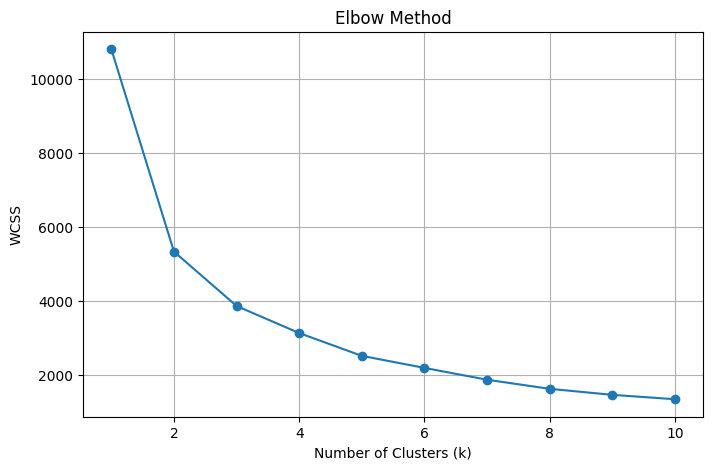

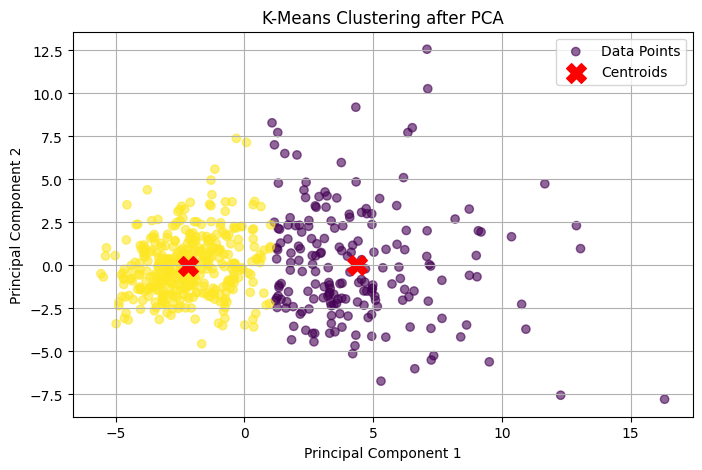

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the dataset
data = pd.read_csv("/content/Breast_Cancer_Dataset.csv")

# Drop unnecessary columns
df = data.drop(['id', 'Unnamed: 32'], axis=1)

# Encode diagnosis column: M = 1 (malignant), B = 0 (benign)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Separate features
X = df.drop(columns=["diagnosis"])

# Standardize features
X_scaled = StandardScaler().fit_transform(X)

# Apply PCA to reduce to 2 components
X_pca = PCA(n_components=2).fit_transform(X_scaled)

# Elbow method to find optimal k
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

# Plot WCSS vs number of clusters
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

# Apply KMeans with optimal k
optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

# Plot the clusters and centroids
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="viridis", alpha=0.6, label='Data Points')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroids')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering after PCA")
plt.legend()
plt.grid(True)
plt.show()
